# Initialize Spark

This must be done every time you run the notebook.

In [ ]:
import findspark
findspark.init()
findspark.find() # Should return the directory of the Spark home

In [ ]:
import os
from pyspark.sql import SparkSession

os.environ["SPARK_LOCAL_HOSTNAME"] = "localhost"

spark = SparkSession.builder\
        .master("local")\
        .appName("Local Spark")\
        .config('spark.ui.port', '4050')\
        .getOrCreate()
sc = spark.sparkContext

sc

# Exercise: from Big Data to Small(er) Data

Case study: weather measurements from the National Climatic Data Center of the USA

We are provided with the following dataset.

- weather-stations.csv: it contains a list of weather stations that capture weather information every day of every year throughout the world
  - Each station is identified by a StationID
  - Additional information about the stations are available (coordinates, country, elevation, etc.)
  - Not that big: ~30K stations, less than 3MB
- weather-measurements.txt: it contains the data measured by a certain station on a certain date
  - Each weather measurement is identified by a StationID and a Date
  - Measurements provide a lot of information (about temperature, humidity, etc.)
  - Can be pretty big! 30K stations * 365 days * 10 kinds of measurements = ~13GB per year
  - Our file is a simplified -and smaller- version based on the real one

In [ ]:
# dfW = sc.textFile("./datasets/weather-sample-10k.txt")\
#   .map(lambda l: (l[4:15],l[15:19],l[19:21],l[21:23],int(l[87:92])/10,l[92:93]))\
#   .toDF(["stationId","year","month","day","airTemperature","airTemperatureQuality"])
# dfW.show()

from pyspark.sql import functions as F

raw = spark.read.text("./datasets/weather-sample-10k.txt")

dfW = (
    raw
    .select(
        F.trim(F.substring("value", 5, 11)).alias("stationId"),
        F.trim(F.substring("value", 16, 4)).alias("year"),
        F.trim(F.substring("value", 20, 2)).alias("month"),
        F.trim(F.substring("value", 22, 2)).alias("day"),
        (F.trim(F.substring("value", 88, 5)).cast("int") / F.lit(10.0)).alias("airTemperature"),
        F.trim(F.substring("value", 93, 1)).alias("airTemperatureQuality")
    )
)

dfW.show()

In [ ]:
from pyspark.sql.functions import concat
dfS = spark.read.option("delimiter", ",").option("header", "false").csv("./datasets/weather-stations.csv")
dfS = dfS.select(concat(dfS[0],dfS[1]),dfS[2],dfS[3],dfS[4],dfS[5],dfS[6],dfS[7],dfS[8],dfS[9],dfS[10])\
  .toDF("stationId","city","country","state","call","latitude","longitude","elevation","date_begin","date_end")
dfS.show()

Here, we want to exploit a big data tool (Spark) to make the data less expensive to store and still interesting for analytical purposes. In particular, we want to:
- Clean the dataset
- Join the tables
- Produce a small(er) data cube that can be easily accessed by OLAP tools

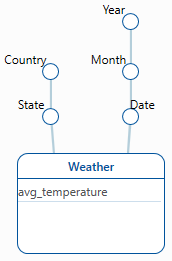

The pipeline can be summarized as follows.

1. Cleaning
    1. On the stations file:
        1. replace empty states and countries in stations with a placeholder value (e.g., "XX");
        1. keep only the following fields: stationId, state, country
    1. On the weather-measurements file:
        1. filter out weather wrong measurements (i.e., where airTemperatureQuality=9);
        1. keep only the following fields: stationId, airTemperature, date, month, year
        1. create a new fulldate field by concatenating year, month, and date in the format "YYYY-MM-DD"
        1. create a new fullmonth field by concatenating year and month in the format "YYYY-MM"
1. Integrating
    1. Join stations with weather measurements on the stationId field
    1. Keep only the following fields: state, country, fulldate, fullmonth, year, airTemperature
1. Summarizing
    1. Aggregate the measurements by state and date to take the average temperature
        - Group by: state, country, fulldate, fullmonth, year
        - Calculation: avg(airTemperature)
1. Save the result on a file

## Spark pipeline

1. Cleaning
    1. On the stations file:
        1. Some states and countries are empty. Replace them with a placeholder value (e.g., "XX").
        1. Some fields are not necessary. Keep only the following ones: stationId, state, country

In [ ]:
dfS1 = dfS.fillna({'state': 'XX', 'country':'XX'})
dfS2 = dfS1.select('stationId','state','country')
dfS2.show()

1. Cleaning
    1. ...
    1. On the weather-sample file:
        1. Some measurements are wrong (i.e., those where airTemperatureQuality=9). Remove them.
        1. Some field are not necessary. Keep only the following ones: stationId, airTemperature, date, month, year.
        1. In the cube, the date field should be the full date ("YYYY-MM-DD"). Create a new fulldate field by concatenating year, month, and date.
        1. In the cube, the month field should include the year ("YYYY-MM"). Create a new fullmonth field by concatenating year and month.

In [ ]:
from pyspark.sql.functions import concat, lit
dfW1 = dfW.where("airTemperatureQuality < 9")
dfW2 = dfW1.select('stationId','airTemperature','day','month','year')
dfW3 = dfW2.withColumn("fulldate", concat(dfW1.year,lit("-"),dfW1.month,lit("-"),dfW1.day))
dfW4 = dfW3.withColumn("fullmonth", concat(dfW1.year,lit("-"),dfW1.month))
dfW4.show()

2. Integrating
    1. Join stations with weather measurements on the stationId field

In [ ]:
dfJ = dfS2.join(dfW4, "stationId")
dfJ.show()

2. Integrating
    1. ...
    1. The stationId is not necessary anymore (we needed it only for the join). Remove it by keeping only the following fields: state, country, fulldate, fullmonth, year, airTemperature.

In [ ]:
dfJ2 = dfJ.select("state", "country", "fulldate", "fullmonth", "year", "airTemperature")
dfJ2.show()

3. Summarizing
    1. Aggregate the measurements by state and date to take the average temperature
        - Group by: state, country, fulldate, fullmonth, year
        - Calculation: avg(airTemperature)

In [ ]:
import pyspark.sql.functions as sf

dfG = dfJ2.groupBy("state", "country", "fulldate", "fullmonth", "year").agg(sf.avg("airTemperature").alias("avg_temperature"))
dfG.show()

4. Save the result on a file

In [ ]:
dfG.write.mode('overwrite').option('header','true').csv("./weather-cube")

# MovieLens

[MovieLens](https://grouplens.org/datasets/movielens/) is a dataset about movies and ratings. You are working with two files:

- ml-movies.csv: contains details about the movies
  - Each movie is identified by ```movieId```
  - Each movie is associated to one or more genres, which are separated by semi-colons (e.g., "Adventure;Children;Fantasy")
- ml-ratings-1m.csv: contains 1 million ratings (in a range from 1 to 5) given by users to movies
  - Each rating is identified by ```movieId``` and ```userId```
  - Each rating is associated to a timestamp (e.g., 1256677221)

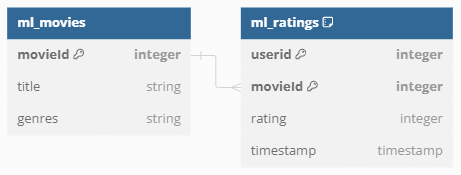

Your goal is to create a single file representing the following cube.

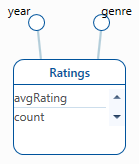

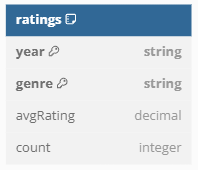

The procedure to create the cube is the following.

1. On the ml-movies.csv file:
  - Each line represents a movie, and each movie has many genres. We want to "explode" the genres, in order to have the same movie repeated for each genre (i.e., the equivalent of the ```flatMap``` on RDDs). To do so, you can use the ```select``` or ```withColumn``` API method in combination with the following:
    - Use the ```split(df['mycolumn'],";")``` to split a column on the semicolon character; it converts from one String to an array of Strings
    - Give the result of the above operation in input to the ```explode_outer()``` function to produce one line per value
  - Replace null genres with the "Undetermined" value; for this, you can use the ```fillna()``` method of the DataFrame APIs
2. On the ml-ratings-1m.csv:
  - Convert the decimal character from comma to dot; for this, you need to create a new column that replaces the character by using the function ```regexp_replace('column_name', ',', '\\.')```; then, create a new column casting to float using ```df['column_name'].cast("float")```
  - Convert the timestamp to the "yyyy" format; to do so, use the ```from_unixtime(dfRatings['my_column'],"mydateformat")``` function to convert from timestamp to the format of your choice
3. Join the two datasets on the ```movieId```
4. Aggregate the data by genre and year to calculate the average rating and count the records; then, sort the results by year and genre using the ```orderBy()``` method
5. Save the result to a file
6. Optional queries:
  - the monthly trends of average ratings, one line per genre;
  - a bar chart showing, for each genre, the number of ratings and/or the average rating

In the process, exclude the fields that are not needed anymore as early as possible (the less data you carry, the better).

Your output should resemble the following:

```
+------------+----+------------------+-----+
|       genre|year|         avgRating|count|
+------------+----+------------------+-----+
|      Action|1996| 3.428543180582332|20229|
|   Adventure|1996|3.4985317672183665|14984|
|   Animation|1996|3.7092354069608113| 3649|
|    Children|1996| 3.517741935483871| 6820|
|      Comedy|1996| 3.404184793867827|24135|
|       Crime|1996|3.6160085203998036|12206|
| Documentary|1996|3.8345864661654137|  266|
|       Drama|1996| 3.700375201000536|27985|
|     Fantasy|1996|3.4779989045097683| 5477|
|   Film-Noir|1996|3.5616438356164384|  146|
|      Horror|1996| 3.516431924882629| 2769|
|        IMAX|1996| 3.888088376560999| 2082|
|     Musical|1996|3.6666666666666665| 3435|
|     Mystery|1996|3.6967410983705493| 3314|
|     Romance|1996|3.6002949852507373|14238|
|      Sci-Fi|1996|3.4102089394340123| 7562|
|    Thriller|1996|3.5943095072866065|21615|
|Undetermined|1996|3.5129533678756477|  386|
|         War|1996|3.9569221628045157| 3366|
|     Western|1996| 3.563403552251136| 2421|
+------------+----+------------------+-----+
```

## Spark

In [ ]:
# WRITE HERE YOUR PIPELINE

# About the exam

- It will a similar version of these pipelines, on a different dataset
    - It will include comprehension questions (like the ones in the first Spark class, on short pieces of code on RDDs and/or DFs) with open-ended answers and/or multiple-choice
- Things considered in the evaluation of code production:
    1. The correctness of the logic of the workflow
    2. The correctness of the code (syntax errors, etc.)
    3. The performance of the code (i.e., no unnecessary operations, getting rid of useless columns as soon as possible)
    4. The addition of comments that explain the logic of the code
- The execution of queries (with comments) on the final result can give bonus points
- The notebook will have to be submitted on Moodle